## Day-3 : Exploratory Data Analysis (EDA), Data Cleaning & Feature Engineering

## Part 1: Exploratory Data Analysis (EDA)

In [1]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Load the Dataset
df = pd.read_csv("used_cars.csv")

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Dataset Structure

In [4]:
df.shape

(4009, 12)

In [5]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## Numerical and Categorical Features

In [7]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:")
print(numerical_columns)

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
Index(['model_year'], dtype='object')

Categorical Features:
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


## Descriptive Statistical Analysis

In [8]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [9]:
df.describe(include='object')

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [10]:
## Missing Values Analysis
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [11]:
## Duplicate Records Analysis
df.duplicated().sum()

np.int64(0)

In [12]:
## Unique Values in Categorical Features
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4


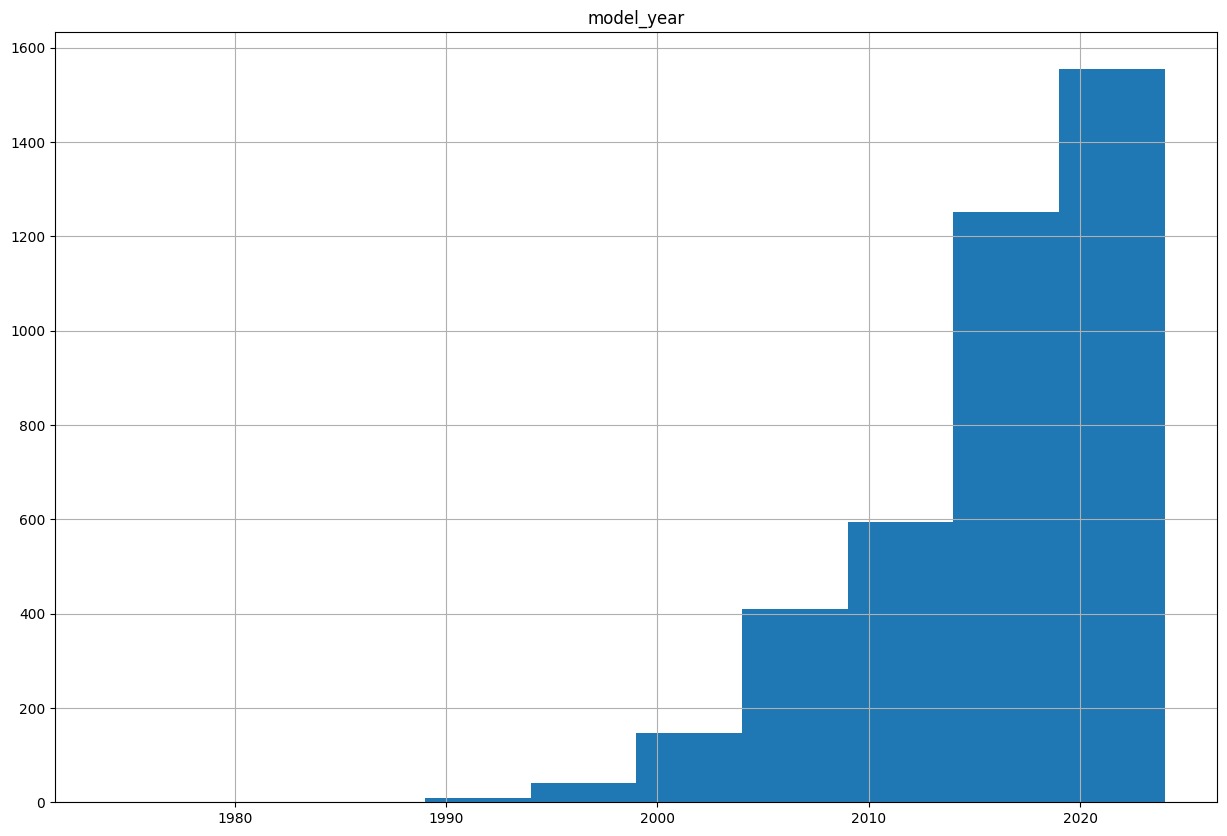

In [13]:
## Distribution of Categorical Features
df.hist(figsize=(15,10))
plt.show()

## Brand Distribution

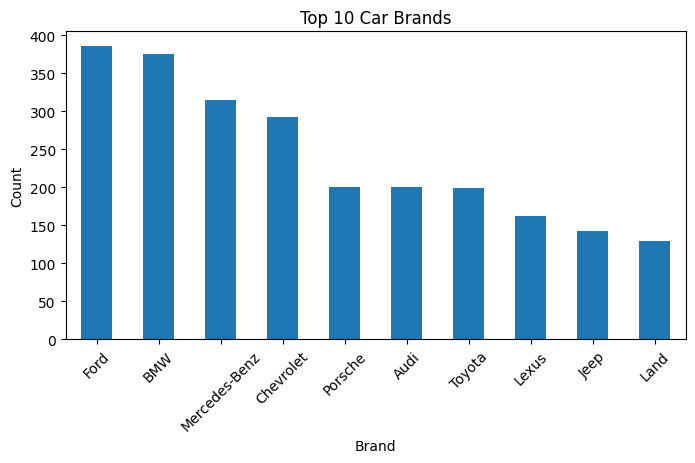

In [14]:
df['brand'].value_counts().head(10).plot(kind='bar', figsize=(8,4))

plt.title("Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Fuel Type Distribution

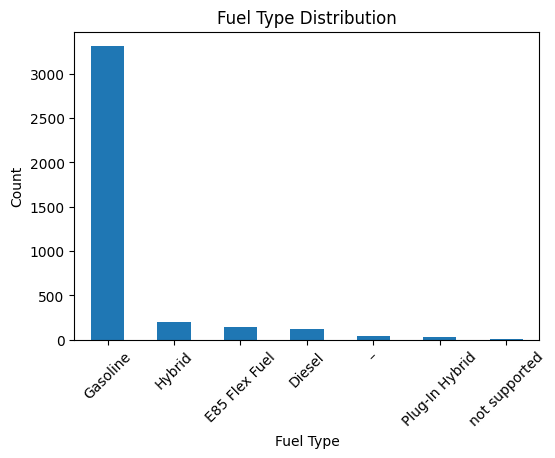

In [15]:
df['fuel_type'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Transmission Distribution

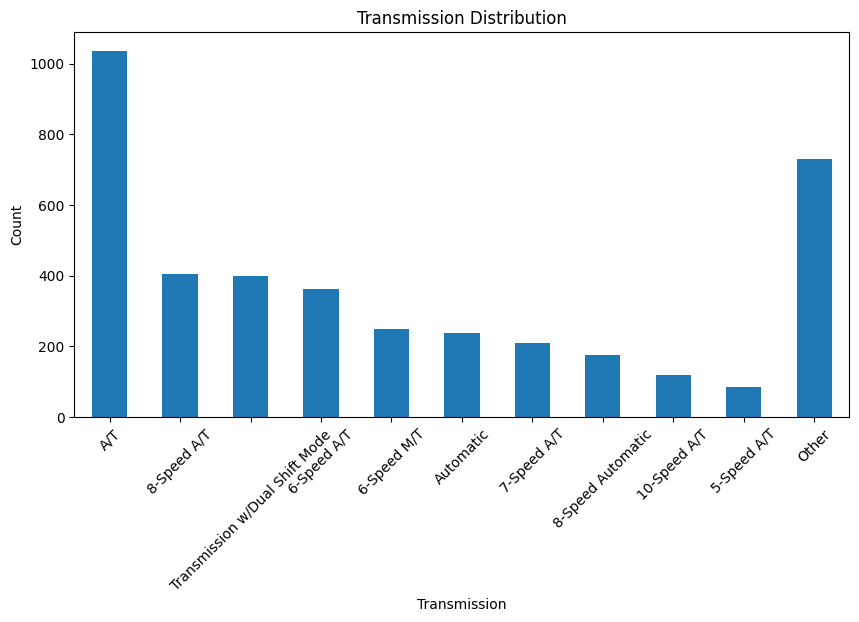

In [16]:
# Count transmission types
transmission_counts = df['transmission'].value_counts()

# Keep the top 10, group the rest as "Other"
top_n = 10

transmission_grouped = transmission_counts.iloc[:top_n].copy()
transmission_grouped["Other"] = transmission_counts.iloc[top_n:].sum()

# Plot
transmission_grouped.plot(kind='bar', figsize=(10,5))

plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Accident History Distribution

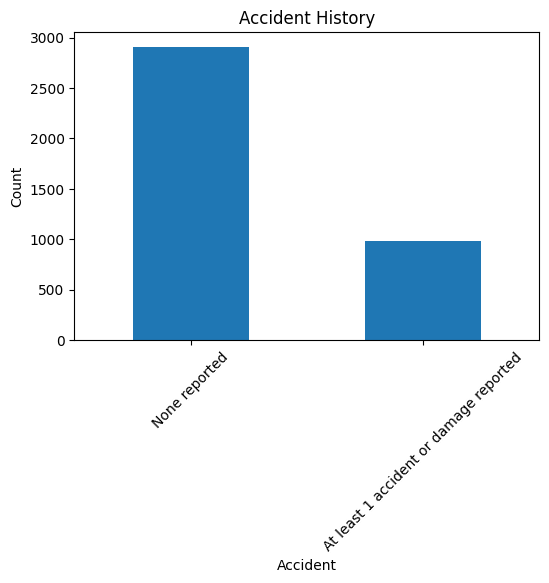

In [17]:
df['accident'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Accident History")
plt.xlabel("Accident")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Clean Title Distribution

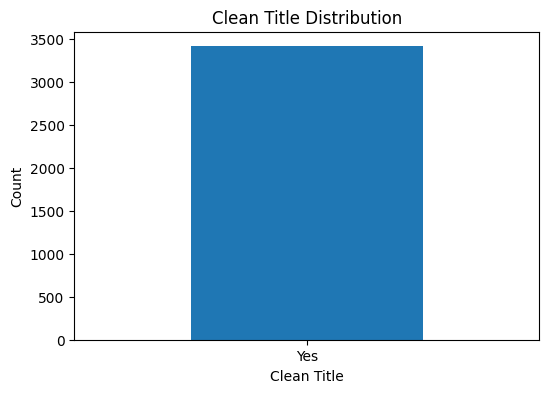

In [18]:
df['clean_title'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Clean Title Distribution")
plt.xlabel("Clean Title")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Outlier Analysis

In [19]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['model_year'], dtype='object')

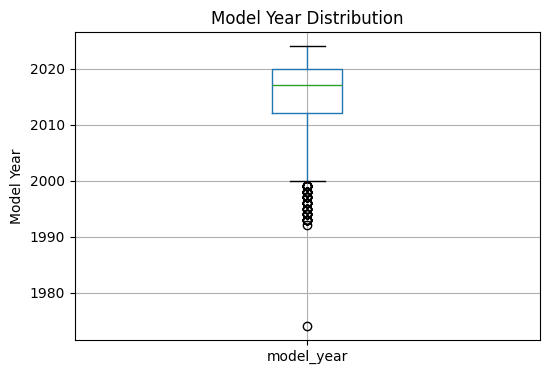

In [20]:
plt.figure(figsize=(6,4))
df.boxplot(column='model_year')

plt.title("Model Year Distribution")
plt.ylabel("Model Year")
plt.show()

### Observation

The boxplot indicates the presence of outliers in the **model_year** feature. These outliers may represent very old or very new vehicles, or they could be due to data entry errors. Before building a machine learning model, these outliers can be handled using techniques such as the Interquartile Range (IQR), Z-score, or by capping extreme values based on domain knowledge.

## Part 2: Data Cleaning & Feature Engineering

In [21]:
## Handle Missing Values
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [22]:
df = df.dropna()

In [23]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df['clean_title'] = df['clean_title'].fillna(df['clean_title'].mode()[0])

In [24]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


### Observation

Missing values were found in the **fuel_type**, **accident**, and **clean_title** columns. Since these are categorical features, the missing values were filled using the most frequent value (mode).

In [25]:
## Remove Duplicate Records
df.duplicated().sum()

np.int64(0)

### Observation

Duplicate records were checked and removed to ensure the dataset contains only unique entries.

## Correct Data Types

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3269 non-null   object
 1   model         3269 non-null   object
 2   model_year    3269 non-null   int64 
 3   milage        3269 non-null   object
 4   fuel_type     3269 non-null   object
 5   engine        3269 non-null   object
 6   transmission  3269 non-null   object
 7   ext_col       3269 non-null   object
 8   int_col       3269 non-null   object
 9   accident      3269 non-null   object
 10  clean_title   3269 non-null   object
 11  price         3269 non-null   object
dtypes: int64(1), object(11)
memory usage: 332.0+ KB


In [27]:
df['milage'].head(10)

,milage
0,"51,000 mi."
1,"34,742 mi."
3,"88,900 mi."
6,"84,000 mi."
7,"242,000 mi."
8,"23,436 mi."
11,"22,770 mi."
12,"12,500 mi."
13,"18,196 mi."
15,"79,800 mi."


In [28]:
df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace(' mi.', '', regex=False)
    .astype(int)
)

In [29]:
df['milage'].head(10)

,milage
0,51000
1,34742
3,88900
6,84000
7,242000
8,23436
11,22770
12,12500
13,18196
15,79800


In [30]:
df['price'].head(10)

,price
0,"$10,300"
1,"$38,005"
3,"$15,500"
6,"$31,000"
7,"$7,300"
8,"$41,927"
11,"$184,606"
12,"$53,500"
13,"$62,000"
15,"$29,990"


In [31]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [32]:
df['price'].head(10)

,price
0,10300
1,38005
3,15500
6,31000
7,7300
8,41927
11,184606
12,53500
13,62000
15,29990


In [33]:
df['price'] = pd.to_numeric(df['price'])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3269 non-null   object
 1   model         3269 non-null   object
 2   model_year    3269 non-null   int64 
 3   milage        3269 non-null   int64 
 4   fuel_type     3269 non-null   object
 5   engine        3269 non-null   object
 6   transmission  3269 non-null   object
 7   ext_col       3269 non-null   object
 8   int_col       3269 non-null   object
 9   accident      3269 non-null   object
 10  clean_title   3269 non-null   object
 11  price         3269 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 332.0+ KB


### Observation

The **milage** and **price** columns were converted from text (object) to numeric data types to enable mathematical operations and machine learning.

## Handle Outliers

In [35]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(df.shape)

(3084, 12)


### Observation

Outliers in the **price** column were identified using the Interquartile Range (IQR) method and removed to improve data quality for future machine learning models.

## Feature Engineering

In [36]:
# 1. Car Age
df['car_age'] = 2025 - df['model_year']

# 2. Mileage Per Year
df['mileage_per_year'] = df['milage'] / (df['car_age'] + 1)

# 3. Luxury Brand Indicator
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Land Rover']

df['is_luxury_brand'] = df['brand'].isin(luxury_brands).astype(int)

# 4. Accident Indicator
df['has_accident'] = (df['accident'] != 'None reported').astype(int)

# 5. Clean Title Indicator
df['has_clean_title'] = (df['clean_title'] == 'Yes').astype(int)

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,mileage_per_year,is_luxury_brand,has_accident,has_clean_title
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,12,3923.076923,0,1,1
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,4,6948.400000,0,1,1
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,10,8081.818182,0,0,1
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,8,9333.333333,1,0,1
7,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,24,9680.000000,1,0,1


### Engineered Features

The following new features were created:

1. **car_age** – Age of the car based on the model year.
2. **mileage_per_year** – Average mileage driven per year.
3. **is_luxury_brand** – Indicates whether the car belongs to a luxury brand.
4. **has_accident** – Indicates whether the car has a reported accident history.
5. **has_clean_title** – Indicates whether the car has a clean title.

In [37]:
## Save Cleaned Dataset
df.to_csv("cleaned_used_cars.csv", index=False)

In [38]:
from google.colab import files
files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final Observation

The dataset has been successfully cleaned, processed, and enriched with new features. It is now ready for machine learning model development and has been saved as **cleaned_used_cars.csv**.

# Key Insights

1. The dataset contains more vehicles from a few popular brands, indicating an imbalanced brand distribution.

2. Most vehicles use gasoline and automatic transmissions, making them the dominant categories in the dataset.

3. Missing values were present in the **fuel_type**, **accident**, and **clean_title** columns and were successfully handled using the mode.

4. The **price** column contained outliers, which were removed using the Interquartile Range (IQR) method to improve data quality.

5. Five new features—**car_age**, **mileage_per_year**, **is_luxury_brand**, **has_accident**, and **has_clean_title**—were created to enhance the dataset for future machine learning models.